In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv("data/pl_24-25_matches_clean.csv")

df.head()

,id,gameweek,dayofweek,date,start_time,home_team,home_xg,score,away_xg,away_team,attendance,venue,referee,notes,last_updated
0,1,1,Fri,2024-08-16,20:00,Manchester Utd,2.4,1–0,0.4,Fulham,NaN,Old Trafford,Robert Jones,NaN,2026-01-13 18:34:33.302
1,2,1,Sat,2024-08-17,12:30,Ipswich Town,0.5,0–2,2.6,Liverpool,NaN,Portman Road Stadium,Tim Robinson,NaN,2026-01-13 18:34:33.302
2,3,1,Sat,2024-08-17,15:00,Newcastle Utd,0.3,1–0,1.8,Southampton,NaN,St James' Park,Craig Pawson,NaN,2026-01-13 18:34:33.302
3,4,1,Sat,2024-08-17,15:00,Everton,0.5,0–3,1.4,Brighton,NaN,Goodison Park,Simon Hooper,NaN,2026-01-13 18:34:33.302
4,5,1,Sat,2024-08-17,15:00,Nott'ham Forest,1.3,1–1,1.2,Bournemouth,NaN,The City Ground,Michael Oliver,NaN,2026-01-13 18:34:33.302


In [3]:
df.shape

(380, 15)

In [4]:
df.columns

Index(['id', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team',
       'home_xg', 'score', 'away_xg', 'away_team', 'attendance', 'venue',
       'referee', 'notes', 'last_updated'],
      dtype='str')

In [5]:
df["score"].head(10)

0    1–0
1    0–2
2    1–0
3    0–3
4    1–1
5    2–0
6    1–2
7    2–1
8    0–2
9    1–1
Name: score, dtype: str

In [7]:
# Split score column into two parts
df[["home_goals", "away_goals"]] = df["score"].str.split("–", expand=True)

# Convert to integers
df["home_goals"] = df["home_goals"].astype(int)
df["away_goals"] = df["away_goals"].astype(int)

df[["home_goals", "away_goals"]].head()

,home_goals,away_goals
0,1,0
1,0,2
2,1,0
3,0,3
4,1,1


In [8]:
df["total_goals"] = df["home_goals"] + df["away_goals"]
df[["home_goals", "away_goals", "total_goals"]].head()

,home_goals,away_goals,total_goals
0,1,0,1
1,0,2,2
2,1,0,1
3,0,3,3
4,1,1,2


In [9]:
def get_result(row):
    if row["home_goals"] > row["away_goals"]:
        return "Home Win"
    elif row["home_goals"] < row["away_goals"]:
        return "Away Win"
    else:
        return "Draw"
df["result"] = df.apply(get_result, axis=1)
df[["home_goals", "away_goals", "result"]].head()

,home_goals,away_goals,result
0,1,0,Home Win
1,0,2,Away Win
2,1,0,Home Win
3,0,3,Away Win
4,1,1,Draw


In [10]:
# Home Points
df["home_points"] = df["result"].apply(lambda x: 3 if x == "Home Win" else (1 if x == "Draw" else 0))

#away points
df["away points"] = df["result"].apply(lambda x: 3 if x == "Away Win" else (1 if x == "Draw" else 0))

df [["home_team", "home_points", "away_team", "away points"]].head()

,home_team,home_points,away_team,away points
0,Manchester Utd,3,Fulham,0
1,Ipswich Town,0,Liverpool,3
2,Newcastle Utd,3,Southampton,0
3,Everton,0,Brighton,3
4,Nott'ham Forest,1,Bournemouth,1


In [12]:
df[["home_goals", "away_goals"]] = df["score"].str.split("–", expand=True)

df["home_goals"] = df["home_goals"].astype(int)
df["away_goals"] = df["away_goals"].astype(int)

df["total_goals"] = df["home_goals"] + df["away_goals"]

In [13]:
def get_result(row):
    if row["home_goals"] > row["away_goals"]:
        return "Home Win"
    elif row["home_goals"] < row["away_goals"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(get_result, axis=1)

In [14]:
df["home_points"] = df["result"].apply(
    lambda x: 3 if x == "Home Win" else (1 if x == "Draw" else 0)
)

df["away_points"] = df["result"].apply(
    lambda x: 3 if x == "Away Win" else (1 if x == "Draw" else 0)
)

In [15]:
# Home stats aggregation
home_table = df.groupby("home_team").agg(
    home_goals_scored=("home_goals", "sum"),
    home_goals_conceded=("away_goals", "sum"),
    home_points=("home_points", "sum")
)

# Away stats aggregation
away_table = df.groupby("away_team").agg(
    away_goals_scored=("away_goals", "sum"),
    away_goals_conceded=("home_goals", "sum"),
    away_points=("away_points", "sum")
)

# Rename away index to match home
away_table.index.name = "home_team"

# Combine both
league_table = home_table.join(away_table)

# Create totals
league_table["goals_scored"] = league_table["home_goals_scored"] + league_table["away_goals_scored"]
league_table["goals_conceded"] = league_table["home_goals_conceded"] + league_table["away_goals_conceded"]
league_table["points"] = league_table["home_points"] + league_table["away_points"]

# Goal difference
league_table["goal_difference"] = league_table["goals_scored"] - league_table["goals_conceded"]

# Sort by points then goal difference
league_table = league_table.sort_values(
    by=["points", "goal_difference"],
    ascending=False
)

league_table.head()

,home_goals_scored,home_goals_conceded,home_points,away_goals_scored,away_goals_conceded,away_points,goals_scored,goals_conceded,points,goal_difference
home_team,,,,,,,,,,
Liverpool,42,16,46,44,25,38,86,41,84,45
Arsenal,35,17,39,34,17,35,69,34,74,35
Manchester City,43,23,42,29,21,29,72,44,71,28
Chelsea,35,18,41,29,25,28,64,43,69,21
Newcastle Utd,40,20,38,28,27,28,68,47,66,21


In [16]:
# Keep only important columns
final_table = league_table[[
    "goals_scored",
    "goals_conceded",
    "goal_difference",
    "points"
]]

final_table.head()

,goals_scored,goals_conceded,goal_difference,points
home_team,,,,
Liverpool,86,41,45,84
Arsenal,69,34,35,74
Manchester City,72,44,28,71
Chelsea,64,43,21,69
Newcastle Utd,68,47,21,66


In [17]:
final_table = final_table.reset_index()

final_table["position"] = range(1, len(final_table) + 1)

final_table = final_table[[
    "position",
    "home_team",
    "points",
    "goals_scored",
    "goals_conceded",
    "goal_difference"
]]

final_table.head()

,position,home_team,points,goals_scored,goals_conceded,goal_difference
0,1,Liverpool,84,86,41,45
1,2,Arsenal,74,69,34,35
2,3,Manchester City,71,72,44,28
3,4,Chelsea,69,64,43,21
4,5,Newcastle Utd,66,68,47,21


In [18]:
import matplotlib.pyplot as plt

top10 = final_table.head(10)

plt.figure()
plt.bar(top10["home_team"], top10["points"])
plt.xticks(rotation=45)
plt.xlabel("Team")
plt.ylabel("Points")
plt.title("Top 10 Teams by Points")
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [19]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------- ----- 7.1/8.1 MB 38.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 28.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 35.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------------- - 6.8/7.0 MB 36.1 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 23.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
  

Matplotlib is building the font cache; this may take a moment.


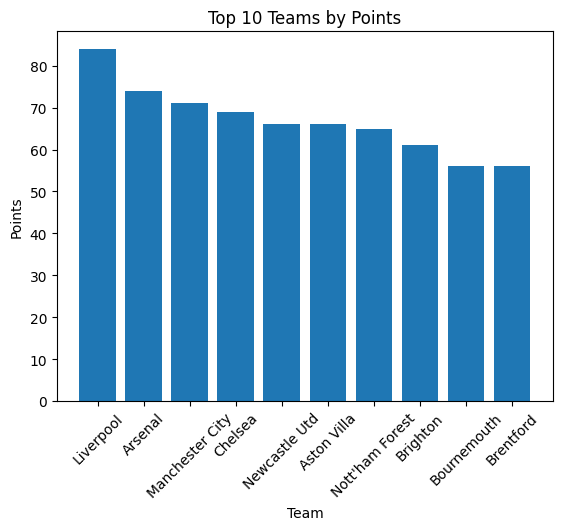

In [20]:
import matplotlib.pyplot as plt

top10 = final_table.head(10)

plt.figure()
plt.bar(top10["home_team"], top10["points"])
plt.xticks(rotation=45)
plt.xlabel("Team")
plt.ylabel("Points")
plt.title("Top 10 Teams by Points")
plt.show()

In [21]:
home_wins = (df["result"] == "Home Win").sum()
away_wins = (df["result"] == "Away Win").sum()
draws = (df["result"] == "Draw").sum()

home_wins, away_wins, draws

(np.int64(155), np.int64(132), np.int64(93))

In [22]:
total_matches = len(df)

home_win_pct = (home_wins / total_matches) * 100
away_win_pct = (away_wins / total_matches) * 100
draw_pct = (draws / total_matches) * 100

home_win_pct, away_win_pct, draw_pct

(np.float64(40.78947368421053),
 np.float64(34.73684210526316),
 np.float64(24.47368421052632))

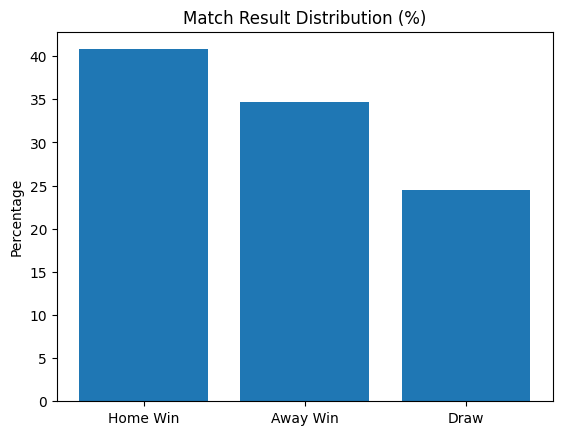

In [23]:
labels = ["Home Win", "Away Win", "Draw"]
values = [home_win_pct, away_win_pct, draw_pct]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Percentage")
plt.title("Match Result Distribution (%)")
plt.show()

In [24]:
df["total_goals"].mean()

np.float64(2.9342105263157894)

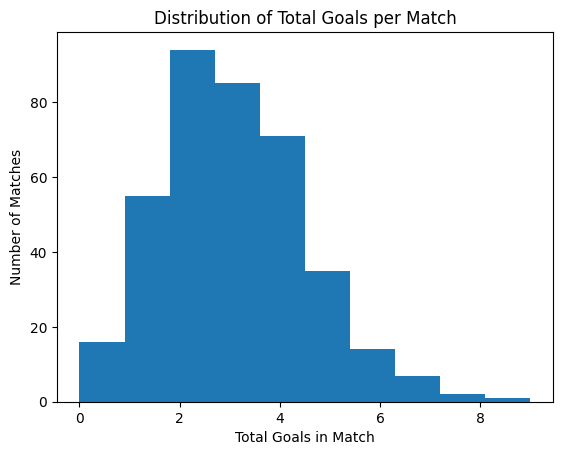

In [25]:
plt.figure()
plt.hist(df["total_goals"], bins=10)
plt.xlabel("Total Goals in Match")
plt.ylabel("Number of Matches")
plt.title("Distribution of Total Goals per Match")
plt.show()

In [26]:
top_matches = df.sort_values(by="total_goals", ascending=False)[
    ["home_team", "away_team", "home_goals", "away_goals", "total_goals"]
].head(10)

top_matches

,home_team,away_team,home_goals,away_goals,total_goals
168,Tottenham,Liverpool,3,6,9
17,Wolves,Chelsea,2,6,8
61,Brentford,Wolves,5,3,8
83,Brentford,Ipswich Town,4,3,7
259,Newcastle Utd,Nott'ham Forest,4,3,7
309,Manchester City,Crystal Palace,5,2,7
347,Brentford,Manchester Utd,4,3,7
125,West Ham,Arsenal,2,5,7
147,Tottenham,Chelsea,3,4,7
229,Nott'ham Forest,Brighton,7,0,7


In [27]:
top_scoring = final_table.sort_values(by="goals_scored", ascending=False)[
    ["home_team", "goals_scored"]
].head(10)

top_scoring

,home_team,goals_scored
0,Liverpool,86
2,Manchester City,72
1,Arsenal,69
4,Newcastle Utd,68
9,Brentford,66
7,Brighton,66
3,Chelsea,64
16,Tottenham,64
6,Nott'ham Forest,58
8,Bournemouth,58


In [28]:
best_defense = final_table.sort_values(by="goals_conceded", ascending=True)[
    ["home_team", "goals_conceded"]
].head(10)

best_defense

,home_team,goals_conceded
1,Arsenal,34
0,Liverpool,41
3,Chelsea,43
2,Manchester City,44
12,Everton,44
6,Nott'ham Forest,46
8,Bournemouth,46
4,Newcastle Utd,47
11,Crystal Palace,51
5,Aston Villa,51


In [29]:
final_table[final_table["home_team"].isin(["Liverpool", "Arsenal"])]

,position,home_team,points,goals_scored,goals_conceded,goal_difference
0,1,Liverpool,84,86,41,45
1,2,Arsenal,74,69,34,35


In [30]:
final_table["goals_scored"].corr(final_table["points"])

np.float64(0.8926623302704172)

In [31]:
final_table["goals_conceded"].corr(final_table["points"])

np.float64(-0.9086628907769998)

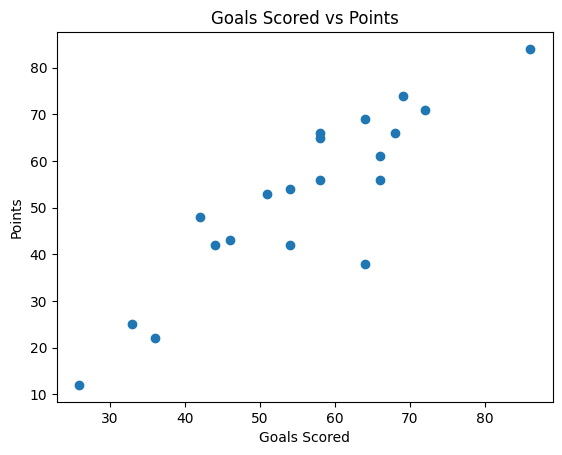

In [32]:
plt.figure()
plt.scatter(final_table["goals_scored"], final_table["points"])
plt.xlabel("Goals Scored")
plt.ylabel("Points")
plt.title("Goals Scored vs Points")
plt.show()

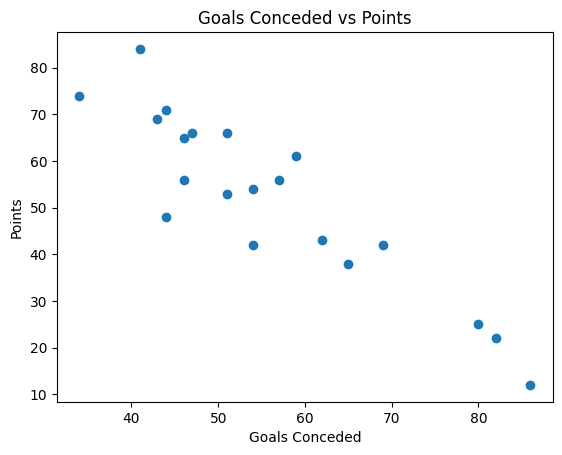

In [33]:
plt.figure()
plt.scatter(final_table["goals_conceded"], final_table["points"])
plt.xlabel("Goals Conceded")
plt.ylabel("Points")
plt.title("Goals Conceded vs Points")
plt.show()

In [34]:
final_table["matches_played"] = 38  # EPL season fixed

final_table["ppg"] = final_table["points"] / final_table["matches_played"]

final_table[["home_team", "points", "ppg"]].head()

,home_team,points,ppg
0,Liverpool,84,2.210526
1,Arsenal,74,1.947368
2,Manchester City,71,1.868421
3,Chelsea,69,1.815789
4,Newcastle Utd,66,1.736842


In [35]:
# Create home team dataframe
home_df = df[["date", "home_team", "home_goals", "away_goals", "home_points"]].copy()
home_df.columns = ["date", "team", "goals_scored", "goals_conceded", "points"]

# Create away team dataframe
away_df = df[["date", "away_team", "away_goals", "home_goals", "away_points"]].copy()
away_df.columns = ["date", "team", "goals_scored", "goals_conceded", "points"]

# Combine both
team_matches = pd.concat([home_df, away_df])

team_matches["date"] = pd.to_datetime(team_matches["date"])
team_matches = team_matches.sort_values(["team", "date"])

team_matches.head()

,date,team,goals_scored,goals_conceded,points
5,2024-08-17,Arsenal,2,0,3
16,2024-08-24,Arsenal,2,0,3
20,2024-08-31,Arsenal,1,1,1
38,2024-09-15,Arsenal,1,0,3
49,2024-09-22,Arsenal,2,2,1


In [36]:
team_matches["rolling_5_points"] = (
    team_matches.groupby("team")["points"]
    .rolling(5)
    .sum()
    .reset_index(level=0, drop=True)
)

team_matches.head(15)

,date,team,goals_scored,goals_conceded,points,rolling_5_points
5,2024-08-17,Arsenal,2,0,3,NaN
16,2024-08-24,Arsenal,2,0,3,NaN
20,2024-08-31,Arsenal,1,1,1,NaN
38,2024-09-15,Arsenal,1,0,3,NaN
49,2024-09-22,Arsenal,2,2,1,11.0
53,2024-09-28,Arsenal,4,2,3,11.0
65,2024-10-05,Arsenal,3,1,3,11.0
76,2024-10-19,Arsenal,0,2,0,10.0
89,2024-10-27,Arsenal,2,2,1,8.0
90,2024-11-02,Arsenal,0,1,0,7.0


In [37]:
# Home xG
home_xg = df.groupby("home_team")["home_xg"].sum()

# Away xG
away_xg = df.groupby("away_team")["away_xg"].sum()
away_xg.index.name = "home_team"

# Combine
total_xg = home_xg + away_xg

final_table["total_xg"] = total_xg.values

In [38]:
final_table["xg_difference"] = final_table["goals_scored"] - final_table["total_xg"]

final_table[["home_team", "goals_scored", "total_xg", "xg_difference"]].head()

,home_team,goals_scored,total_xg,xg_difference
0,Liverpool,86,60.0,26.0
1,Arsenal,69,56.0,13.0
2,Manchester City,72,63.8,8.2
3,Chelsea,64,59.0,5.0
4,Newcastle Utd,68,58.5,9.5


In [39]:
top4 = final_table.head(4)["home_team"].tolist()
top4

['Liverpool', 'Arsenal', 'Manchester City', 'Chelsea']

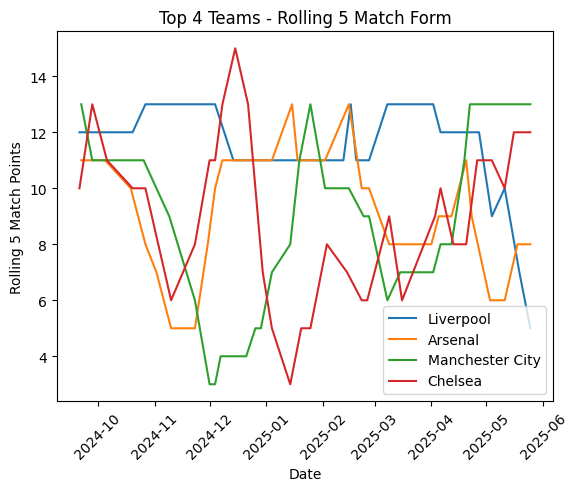

In [40]:
import matplotlib.pyplot as plt

plt.figure()

for team in top4:
    team_data = team_matches[team_matches["team"] == team]
    plt.plot(team_data["date"], team_data["rolling_5_points"], label=team)

plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Rolling 5 Match Points")
plt.title("Top 4 Teams - Rolling 5 Match Form")
plt.legend()
plt.show()

In [41]:
xg_rank = final_table.sort_values(by="xg_difference", ascending=False)[
    ["home_team", "goals_scored", "total_xg", "xg_difference"]
]

xg_rank.head(10)

,home_team,goals_scored,total_xg,xg_difference
9,Brentford,66,34.3,31.7
16,Tottenham,64,32.5,31.5
0,Liverpool,86,60.0,26.0
7,Brighton,66,42.0,24.0
10,Fulham,54,32.7,21.3
1,Arsenal,69,56.0,13.0
4,Newcastle Utd,68,58.5,9.5
8,Bournemouth,58,49.1,8.9
15,Wolves,54,45.3,8.7
2,Manchester City,72,63.8,8.2


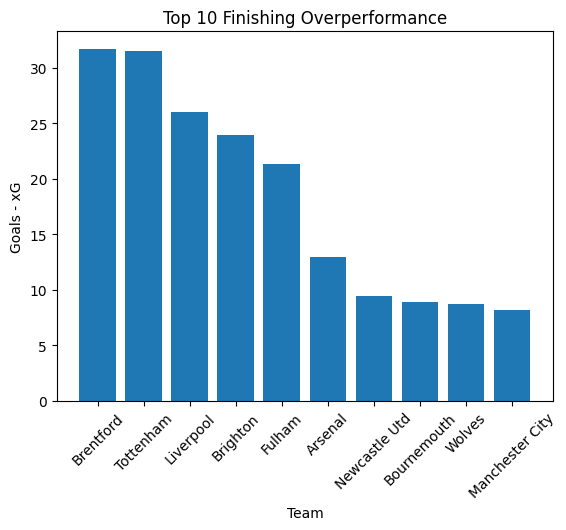

In [42]:
top_xg = xg_rank.head(10)

plt.figure()
plt.bar(top_xg["home_team"], top_xg["xg_difference"])
plt.xticks(rotation=45)
plt.xlabel("Team")
plt.ylabel("Goals - xG")
plt.title("Top 10 Finishing Overperformance")
plt.show()

In [43]:
final_table["attack_index"] = final_table["goals_scored"] / final_table["goals_scored"].max()

final_table["defense_index"] = 1 - (
    final_table["goals_conceded"] / final_table["goals_conceded"].max()
)

final_table["efficiency_score"] = (
    final_table["attack_index"] +
    final_table["defense_index"]
) / 2

In [44]:
efficiency_rank = final_table.sort_values(by="efficiency_score", ascending=False)[
    ["home_team", "efficiency_score"]
]

efficiency_rank.head(10)

,home_team,efficiency_score
0,Liverpool,0.761628
1,Arsenal,0.703488
2,Manchester City,0.662791
3,Chelsea,0.622093
4,Newcastle Utd,0.622093
6,Nott'ham Forest,0.569767
8,Bournemouth,0.569767
9,Brentford,0.552326
7,Brighton,0.540698
5,Aston Villa,0.540698
